In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

wine = load_diabetes()
df = pd.DataFrame(data=wine.data,columns=wine.feature_names)
df['target'] = wine.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
# 컬렴명 확인
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='str')

Text(0.5, 1.0, 'Label')

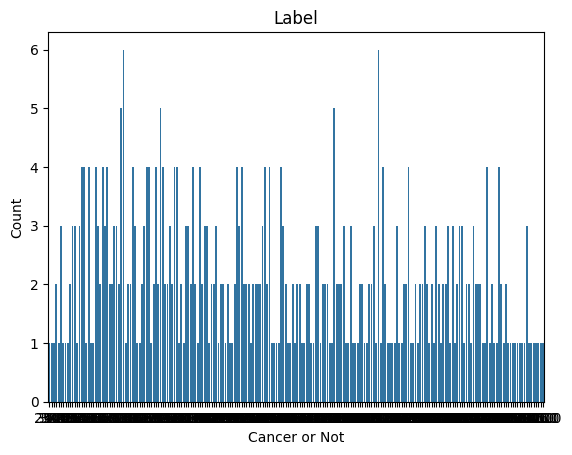

In [3]:
# 레이블 갯수 확인 (그래프)
sns.countplot(data = df, x="target")
plt.xlabel("Cancer or Not")
plt.ylabel("Count")
plt.title("Label")

In [4]:
# 레이블 갯수 확인 (숫자)
df['target'].value_counts()

target
200.0    6
72.0     6
90.0     5
71.0     5
178.0    5
        ..
146.0    1
212.0    1
120.0    1
183.0    1
57.0     1
Name: count, Length: 214, dtype: int64

In [5]:
# 결측치 확인
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [6]:
# 결측치 제거
df = df.dropna()
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring

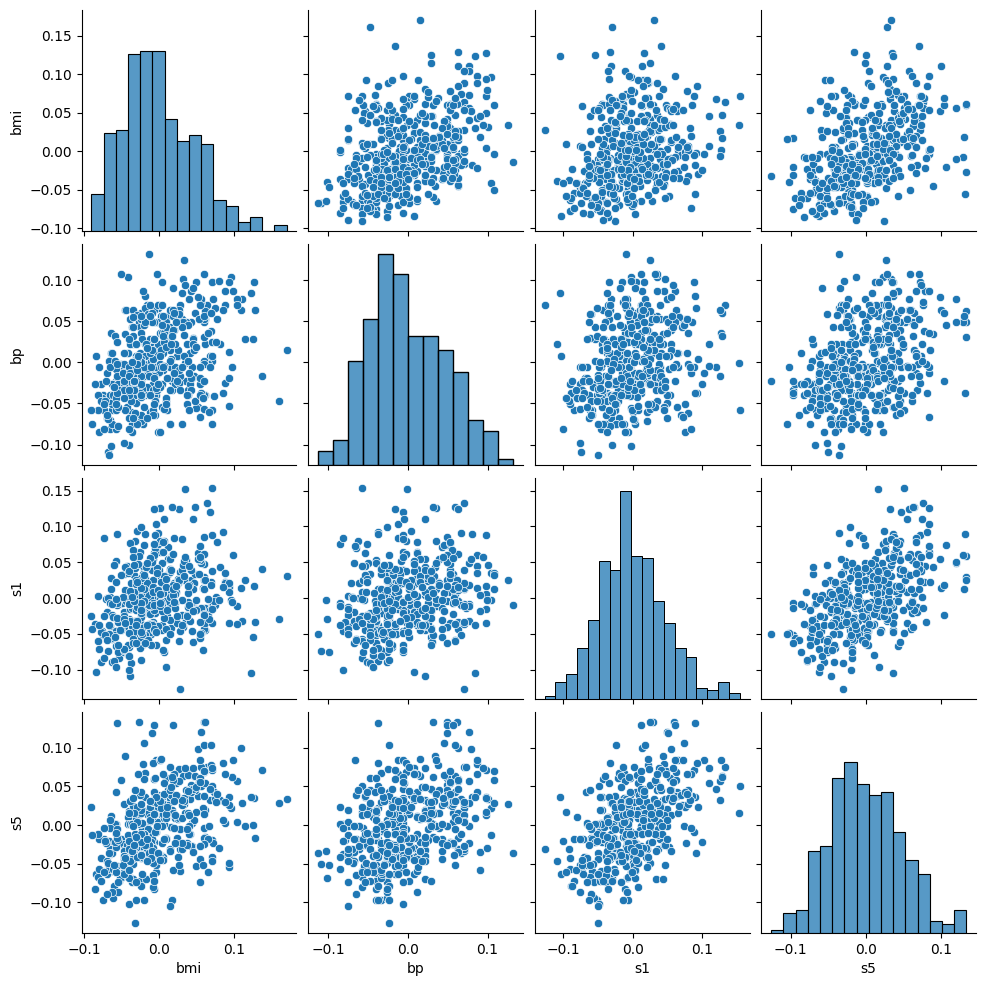

In [7]:
# pairplot로 당뇨 데이터의 주요 특징들 살펴보기
# 변수 선택: bmi(체질량지수), bp(혈압), s1(총콜레스테롤), s5(혈청 측정값)
sns.pairplot(df, 
             vars=['bmi', 'bp', 's1', 's5'], 
             palette='bright')
plt.show()

C:\Users\Jun\AppData\Local\Temp\ipykernel_9716\2450287269.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="bmi", data=df, palette="Set3")


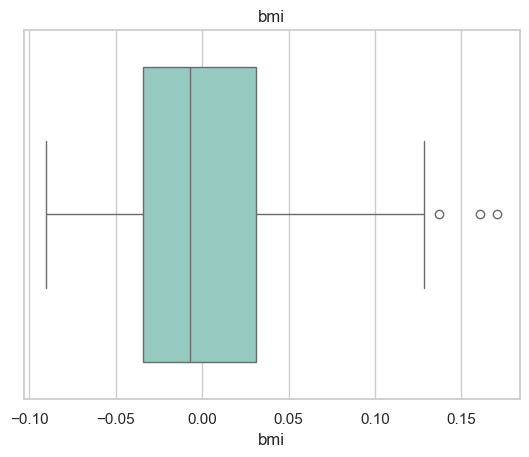

In [8]:
# 특정 칼럼의 범위 확인 및 outlier 확인

sns.set_theme(style="whitegrid")
sns.boxplot(x="bmi", data=df, palette="Set3")
plt.title("bmi")
plt.show()

C:\Users\Jun\AppData\Local\Temp\ipykernel_9716\2498552643.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax = ax)


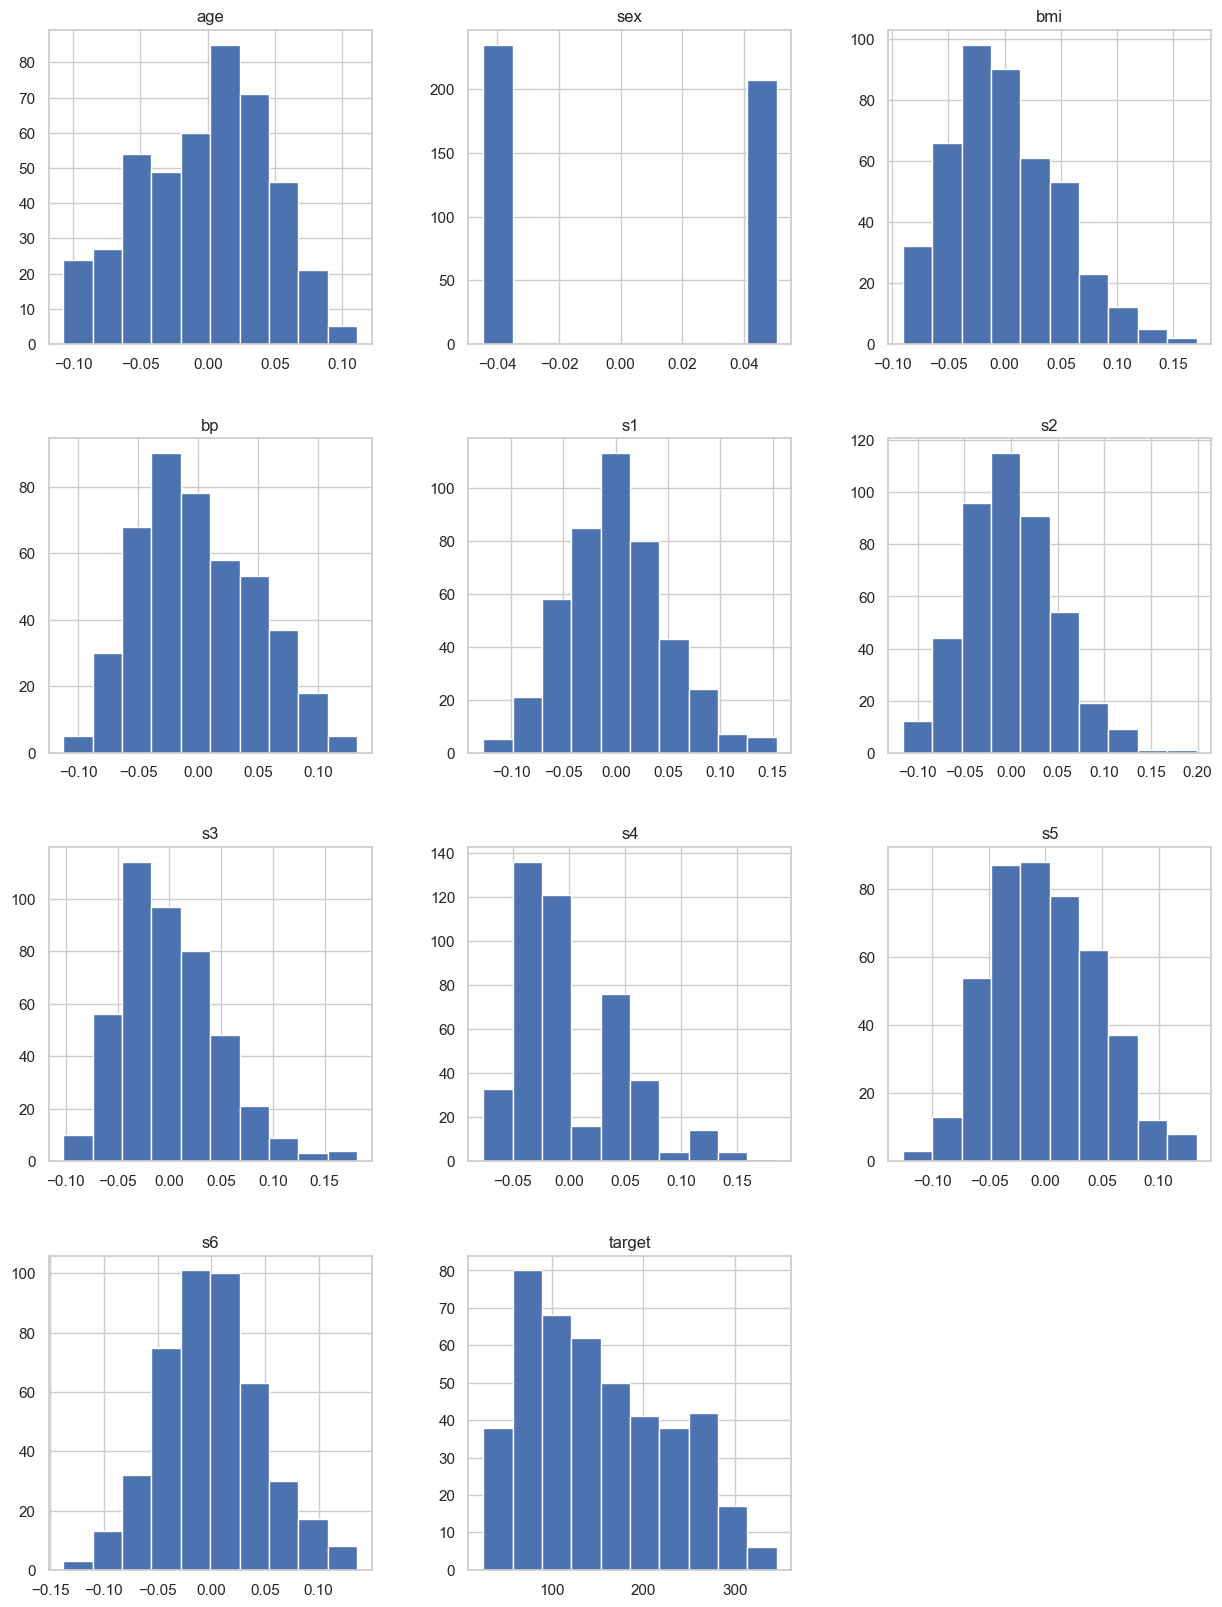

In [9]:
# 각 컬럼별 히스토 그램 확인

fig = plt.figure(figsize = (15,20))
ax = fig.gca()
df.hist(ax = ax)
plt.show()

In [10]:
X=df.drop('target',axis=1)
X.head()
y=df['target']
y.value_counts()
y

0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: target, Length: 442, dtype: float64

In [11]:
Y = y.values   # one-hot 제거, 회귀니까 그대로 사용
X = X.values

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0) 

In [13]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

model = Sequential()

# 입력층: diabetes feature 개수는 10개
model.add(Dense(10, input_shape=(10,), activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(6, activation='relu'))

# 출력층: 회귀이므로 노드 1개, activation 없음
model.add(Dense(1))

# 컴파일: 회귀이므로 loss='mse', metrics='mae'
model.compile(optimizer=Adam(learning_rate=0.04), 
              loss='mse', 
              metrics=['mae'])

model.summary()

C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259 (1.01 KB)

 Trainable params: 259 (1.01 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 1. 모델 학습
model_history = model.fit(x=X_train, 
                          y=y_train, 
                          epochs=30, 
                          batch_size=32, 
                          validation_data=(X_test, y_test))

# 2. 테스트 데이터로 예측 진행
y_pred = model.predict(X_test)



Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 28183.9102 - mae: 148.4665 - val_loss: 24513.5273 - val_mae: 139.5195
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 17752.0078 - mae: 108.8560 - val_loss: 4882.4229 - val_mae: 54.7390
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6366.8730 - mae: 68.3596 - val_loss: 3896.4929 - val_mae: 52.7532
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3991.5063 - mae: 53.5683 - val_loss: 3677.0640 - val_mae: 48.4490
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3683.1826 - mae: 50.6467 - val_loss: 3490.3926 - val_mae: 48.8173
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3433.6846 - mae: 49.2239 - val_loss: 3320.6729 - val_mae: 46.0256
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3181.2603 - mae: 47.1775 - val_loss: 3341.3535 - val_mae: 46.2354
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3251.7869 - mae: 47.6591 - val_loss: 3405.7627 - val_mae: 45.0090
E

In [15]:
from sklearn.metrics import mean_squared_error
print("DNN MSE:", mean_squared_error(y_test, y_pred))

DNN MSE: 3536.8123604254324


In [16]:
clf_df = df.copy()  # 수정: df → df.copy()
clf_df['target'] = pd.cut(clf_df['target'], bins=3, labels=[0, 1, 2]).astype(int)

y = clf_df['target']
y

0      1
1      0
2      1
3      1
4      1
      ..
437    1
438    0
439    0
440    1
441    0
Name: target, Length: 442, dtype: int64

In [17]:
X = clf_df.drop('target', axis=1) # fitting data
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

lg_model = LogisticRegression(random_state=0)
lg_model.fit(X_train,y_train)
lg_y = lg_model.predict(X_test)

De_model = DecisionTreeClassifier(random_state=0)
De_model.fit(X_train,y_train)
De_y = lg_model.predict(X_test)

Rd_model = RandomForestClassifier(random_state=0)
Rd_model.fit(X_train,y_train)
Rd_y = lg_model.predict(X_test)

KN_model = KNeighborsClassifier(n_neighbors=5)
KN_model.fit(X_train,y_train)
KN_y = KN_model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score # 정확도
from sklearn.metrics import confusion_matrix #혼동행렬 ==> k fold

print('---- logistic regression ----')
print(accuracy_score(y_test, lg_y))
print(confusion_matrix(y_test, lg_y))

print('---- decision tree classifier ----')
print(accuracy_score(y_test, De_y))
print(confusion_matrix(y_test, De_y))

print('---- random forest classifier ----')
print(accuracy_score(y_test, Rd_y))
print(confusion_matrix(y_test, Rd_y))

print('---- KNeighborsClassifier ----')
print(accuracy_score(y_test, KN_y))
print(confusion_matrix(y_test, KN_y))

---- logistic regression ----
0.5056179775280899
[[36  3  0]
 [29  8  0]
 [ 7  5  1]]
---- decision tree classifier ----
0.5056179775280899
[[36  3  0]
 [29  8  0]
 [ 7  5  1]]
---- random forest classifier ----
0.5056179775280899
[[36  3  0]
 [29  8  0]
 [ 7  5  1]]
---- KNeighborsClassifier ----
0.6179775280898876
[[31  6  2]
 [16 20  1]
 [ 7  2  4]]


In [21]:
reg_df = df
y = reg_df['target']             # target
y.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

In [22]:
X = reg_df.drop('target', axis=1) # fitting data
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

lg_model = LinearRegression()
lg_model.fit(X_train,y_train)
lg_y = lg_model.predict(X_test)

De_model = DecisionTreeRegressor()
De_model.fit(X_train,y_train)
De_y = lg_model.predict(X_test)

Rd_model = RandomForestRegressor()
Rd_model.fit(X_train,y_train)
Rd_y = lg_model.predict(X_test)

KN_model = KNeighborsRegressor(n_neighbors=5)
KN_model.fit(X_train,y_train)
KN_y = KN_model.predict(X_test)

In [25]:
from sklearn.metrics import mean_squared_error # 평균제곱오차

print('---- LinearRegression ----')
print(mean_squared_error(y_test,lg_y))
print('---- DecisionTreeRegressor ----')
print(mean_squared_error(y_test,De_y))
print('---- RandomForestRegressor ----')
print(mean_squared_error(y_test,Rd_y))
print('---- KNeighborsRegressor ----')
print(mean_squared_error(y_test,KN_y))

---- LinearRegression ----
3424.2593342986925
---- DecisionTreeRegressor ----
3424.2593342986925
---- RandomForestRegressor ----
3424.2593342986925
---- KNeighborsRegressor ----
4243.422022471909
